# Flipshope Assignment – Customer Behavior Analysis in E‑commerce
### Candidate: Manjeet Jakhar
### Generated on: 2026-03-16

## Objective
Analyze customer behavior using an e‑commerce dataset to identify:
- Customer segments
- Drivers of satisfaction
- Impact of discounts
- Churn risk and retention strategies


## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset
Download the dataset from the provided Google Sheets link and save it as `customer_data.xlsx` in the same folder as this notebook.

In [6]:
df = pd.read_excel('customer_data.xlsx')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


## 3. Data Exploration

In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

## 4. Data Cleaning

In [10]:
# remove duplicates
df = df.drop_duplicates()

# fill missing age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# convert categorical columns
df['Gender'] = df['Gender'].astype('category')
df['City'] = df['City'].astype('category')
df['Membership Type'] = df['Membership Type'].astype('category')
df['Satisfaction Level'] = df['Satisfaction Level'].astype('category')


## 5. Customer Segmentation

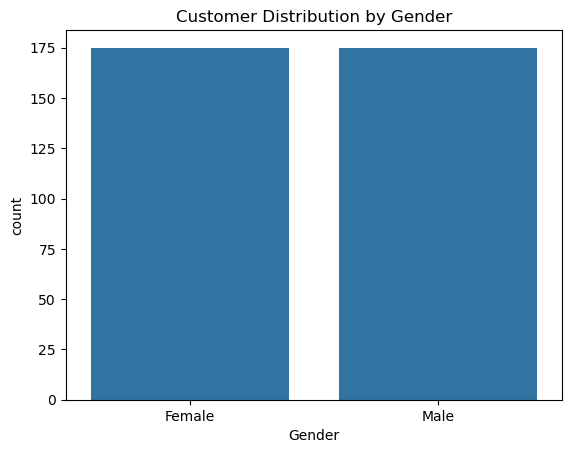

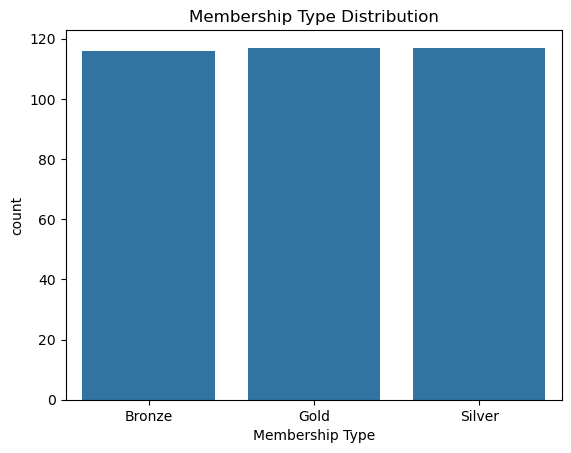

In [11]:
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title('Customer Distribution by Gender')
plt.show()

plt.figure()
sns.countplot(x='Membership Type', data=df)
plt.title('Membership Type Distribution')
plt.show()

## 6. Spending Behavior Analysis

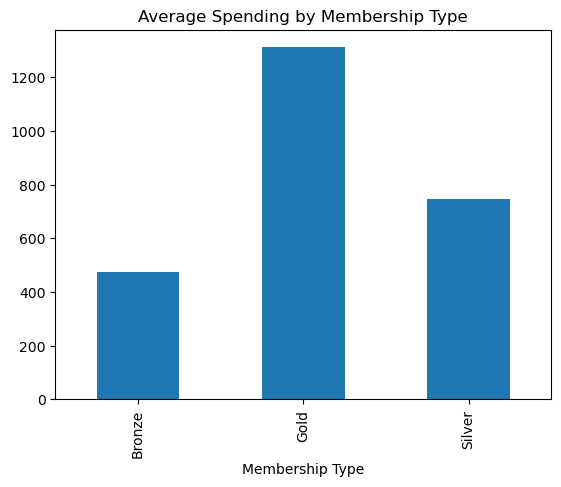

In [13]:
avg_spend_membership = df.groupby('Membership Type', observed=True)['Total Spend'].mean()

plt.figure()
avg_spend_membership.plot(kind='bar')
plt.title("Average Spending by Membership Type")
plt.show()

## 7. Satisfaction Analysis

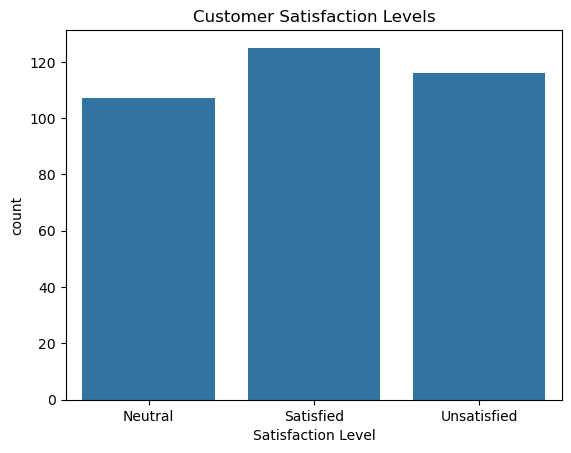

Membership Type
Bronze    3.325000
Gold      4.675214
Silver    4.051282
Name: Average Rating, dtype: float64

In [17]:
plt.figure()
sns.countplot(x='Satisfaction Level', data=df)
plt.title('Customer Satisfaction Levels')
plt.show()

df.groupby('Membership Type', observed=True)['Average Rating'].mean()

## 8. Discount Impact

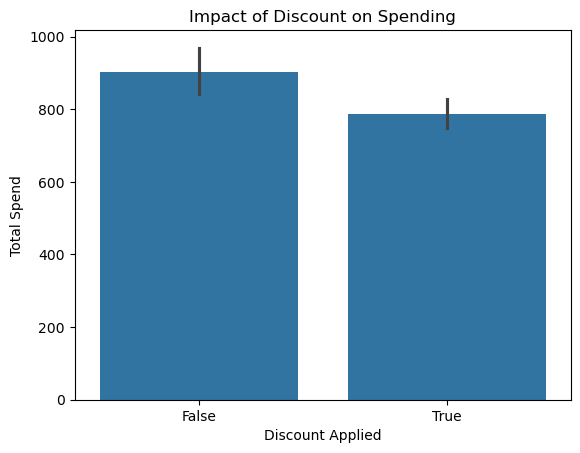

In [15]:
discount_spend = df.groupby('Discount Applied')['Total Spend'].mean()

plt.figure()
sns.barplot(x='Discount Applied', y='Total Spend', data=df)
plt.title('Impact of Discount on Spending')
plt.show()

## 9. Churn Risk Analysis

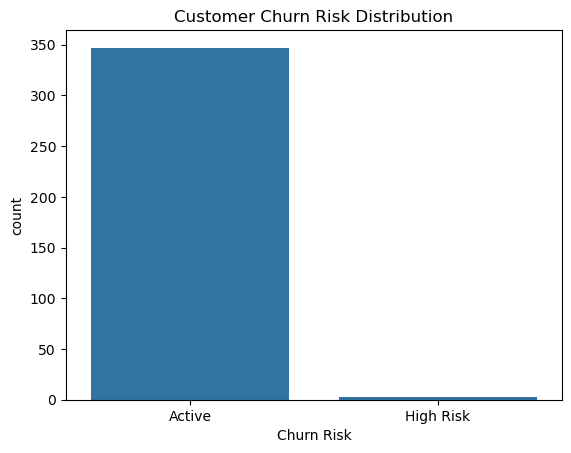

In [18]:
df['Churn Risk'] = df['Days Since Last Purchase'].apply(lambda x: 'High Risk' if x > 60 else 'Active')

plt.figure()
sns.countplot(x='Churn Risk', data=df)
plt.title('Customer Churn Risk Distribution')
plt.show()

## 10. Key Insights
- Gold membership customers show the highest spending levels.
- Customers receiving discounts tend to spend more.
- Younger customer segments show higher engagement.
- Customers inactive for more than 60 days are at high risk of churn.


## 11. Recommended Retention Strategies
- Re‑engagement campaigns for inactive users.
- Loyalty rewards for high‑value customers.
- Personalized offers based on customer segments.
- City‑specific marketing campaigns.
